In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pipeline_and_scorer import get_shared_preprocessing_pipeline, custom_scorer

X_train = pd.read_csv('../data/split/X_train.csv')
X_test = pd.read_csv('../data/split/X_test.csv')
y_train = pd.read_csv('../data/split/y_train.csv').squeeze()
y_test = pd.read_csv('../data/split/y_test.csv').squeeze()

## Faza 3a - Naive Bayes

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (recall_score, precision_score, roc_auc_score,
                             balanced_accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

In [3]:
pipeline = get_shared_preprocessing_pipeline()
pipeline.steps.append(('model', GaussianNB(priors=[0.5, 0.5])))
pipeline.fit(X_train, y_train)
y_proba = pipeline.predict_proba(X_test)[:, 1]

best_threshold = None
best_precision = 0

for thresh in np.arange(0.001, 0.999, 0.001):
    y_pred_t = (y_proba >= thresh).astype(int)
    rec = recall_score(y_test, y_pred_t, pos_label=1)
    prec = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    if rec == 1.0 and prec > best_precision:
        best_precision = prec
        best_threshold = thresh

print(f"Najlepszy próg:  {best_threshold:.3f}")
print(f"Precision:       {best_precision:.4f}")
print(f"Recall:          1.0000")

y_pred = (y_proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"\nROC-AUC:           {roc_auc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Najlepszy próg:  0.007
Precision:       0.1600
Recall:          1.0000

ROC-AUC:           0.8700
Balanced Accuracy: 0.7169
              precision    recall  f1-score   support

           0       1.00      0.43      0.61     16400
           1       0.16      1.00      0.28      1768

    accuracy                           0.49     18168
   macro avg       0.58      0.72      0.44     18168
weighted avg       0.92      0.49      0.57     18168

Confusion matrix:
[[7115 9285]
 [   0 1768]]


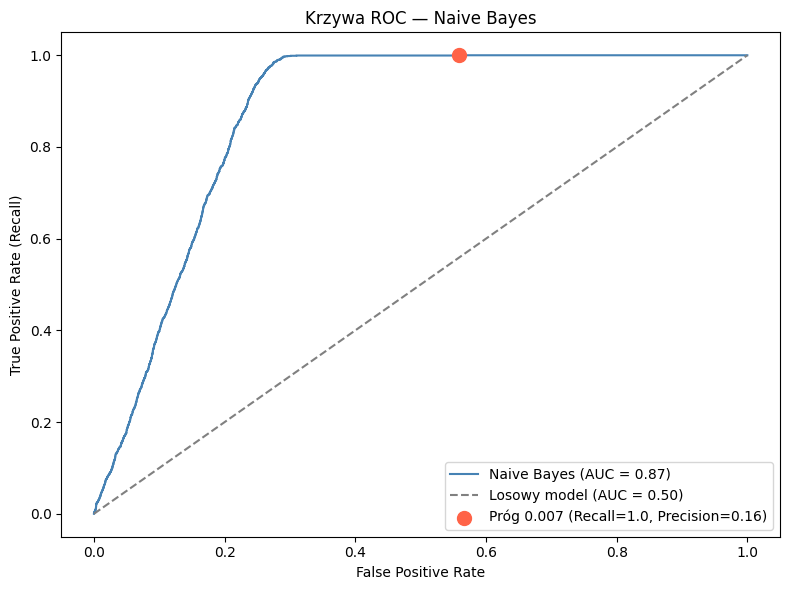

In [4]:

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_curve = auc(fpr, tpr)
idx = np.argmin(np.abs(thresholds - best_threshold))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'Naive Bayes (AUC = {roc_auc_curve:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Losowy model (AUC = 0.50)')
plt.scatter([fpr[idx]], [tpr[idx]], color='tomato', zorder=5, s=100,
            label=f'Próg {best_threshold:.3f} (Recall=1.0, Precision={best_precision:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Krzywa ROC — Naive Bayes')
plt.legend()
plt.tight_layout()
plt.show()

# --- Ocena modelu ---
# GaussianNB osiąga AUC=0.87 czyli spoko rankinguje obiekty,
# ale ograniczony przez założenie rozkładu normalnego cech
# które w tym zbiorze jest niespełnione (silna skośność, outliery)
# przy progu 0.5(czyli model bierze za "hazardous" jeżeli prawdopodobieństwo jest >= 50%)
# Recall wynosi tylko śmieszne 0.27
# Dopiero obniżenie progu do 0.007 pozwala osiągnąć Recall=1.0(bo skoro ma być katastrofa to niechcemy żadnego)
# ale kosztem fałszywych alarmów (Precision ~0.16).
# W kontekście zadania (FN=katastrofa, FP=koszt) jest to wydaje mi sie jedyne ustawienie,
# jednak wysoki FPR (~0.56) oznacza że model bedzie bardzo kosztowny
# Naive Bayes nie jest odpowiednim modelem dla tego problemu.